# Contour Identification & Coloring — from scratch

Identifies every **separate contour** on each tile and paints it a distinct
color. The core routine `label_contours` is a hand-written
**connected-component labeling** algorithm (iterative flood fill) — no
`cv2.findContours`, no `cv2.connectedComponents`, no `scipy.ndimage.label`.

A "separate contour" here = a maximal set of foreground pixels connected to one
another. Two strokes that physically touch or cross are therefore one contour
and share a color; genuinely separating crossing strokes is a different problem
(skeleton-graph tracing, see the closure-analysis notebook).

In [9]:
# === Cell 1 — Imports & data loader ===
import os, glob
from collections import deque
import colorsys
import numpy as np
import cv2                       # used ONLY to decode PNG files into arrays
import matplotlib.pyplot as plt

DATA_DIR     = "./tile/L1000770"   # <-- CHANGE ME: folder with tile_*.png
FG_THRESHOLD = 50    # grayscale intensity above which a pixel is "contour"

def load_tiles(data_dir=DATA_DIR):
    """Load every tile_*.png in data_dir as a grayscale array -> {name: img}."""
    paths = sorted(glob.glob(os.path.join(data_dir, "tile_*.png")))
    if not paths:
        raise FileNotFoundError(f"No tile_*.png found in {data_dir!r}")
    return {os.path.basename(p): cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in paths}

TILES = dict(list(load_tiles().items())[:40])   # take the first 40 tiles
print(f"Loaded {len(TILES)} tile(s) from {DATA_DIR}")
for name, img in TILES.items():
    print(f"  {name:30s} shape={img.shape}")


Loaded 40 tile(s) from ./tile/L1000770
  tile_L1000770_00861.png        shape=(75, 75)
  tile_L1000770_00862.png        shape=(75, 75)
  tile_L1000770_00871.png        shape=(75, 75)
  tile_L1000770_00876.png        shape=(75, 75)
  tile_L1000770_00877.png        shape=(75, 75)
  tile_L1000770_00878.png        shape=(75, 75)
  tile_L1000770_01019.png        shape=(75, 75)
  tile_L1000770_01020.png        shape=(75, 75)
  tile_L1000770_01034.png        shape=(75, 75)
  tile_L1000770_01035.png        shape=(75, 75)
  tile_L1000770_01036.png        shape=(75, 75)
  tile_L1000770_01161.png        shape=(75, 75)
  tile_L1000770_01162.png        shape=(75, 75)
  tile_L1000770_01177.png        shape=(75, 75)
  tile_L1000770_01178.png        shape=(75, 75)
  tile_L1000770_01192.png        shape=(75, 75)
  tile_L1000770_01193.png        shape=(75, 75)
  tile_L1000770_01194.png        shape=(75, 75)
  tile_L1000770_01319.png        shape=(75, 75)
  tile_L1000770_01320.png        shape=(75, 75)
 

## The algorithm — connected-component labeling by flood fill

`label_contours` scans the binary mask in raster order. The first time it meets
an unlabeled foreground pixel it starts a **new component** and grows it with a
breadth-first flood fill, stamping every reachable connected pixel with the same
integer label. When the queue drains, the component is complete and the scan
resumes — so the *k*-th component discovered gets label *k*.

**8-connectivity is the default.** Contour strokes are 1-px thin and often
diagonal; under 4-connectivity a diagonal run would shatter into isolated
pixels. The 8-neighbour rule keeps diagonal strokes intact.

Steps: `binarize → flood-fill label → assign one HSV-spaced color per label`.

In [10]:
# === Cell 2 — From-scratch contour labeling & coloring ===

def label_contours(mask, connectivity=8, min_size=3):
    """
    From-scratch connected-component labeling via iterative (BFS) flood fill.

    Parameters
    ----------
    mask         : 2D bool array  -- True where a contour pixel sits.
    connectivity : 8 (default) or 4 -- neighbourhood used to link pixels.
    min_size     : components with fewer pixels are discarded as noise.

    Returns
    -------
    labels : int32 array, same shape as mask. 0 = background,
             1..N = the N distinct contours (label k = k-th one found).
    """
    H, W = mask.shape
    labels = np.zeros((H, W), dtype=np.int32)

    if connectivity == 8:
        offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    elif connectivity == 4:
        offsets = [(-1,0),(1,0),(0,-1),(0,1)]
    else:
        raise ValueError("connectivity must be 4 or 8")

    next_label = 0
    for r in range(H):
        for c in range(W):
            if not mask[r, c] or labels[r, c] != 0:
                continue                         # background or already labeled

            next_label += 1                      # start a fresh component
            component = []
            queue = deque([(r, c)])
            labels[r, c] = next_label

            while queue:                         # breadth-first flood fill
                y, x = queue.popleft()
                component.append((y, x))
                for dy, dx in offsets:
                    ny, nx = y + dy, x + dx
                    if (0 <= ny < H and 0 <= nx < W
                            and mask[ny, nx] and labels[ny, nx] == 0):
                        labels[ny, nx] = next_label
                        queue.append((ny, nx))

            if len(component) < min_size:        # drop tiny speck, reuse label
                for (y, x) in component:
                    labels[y, x] = 0
                next_label -= 1

    return labels


def make_palette(n, seed=7):
    """n visually-distinct RGB colors via evenly-spaced HSV hues."""
    rng = np.random.RandomState(seed)
    palette = []
    for i in range(n):
        hue = (i / max(n, 1)) % 1.0              # spread hues around the wheel
        sat = 0.70 + 0.30 * rng.rand()
        val = 0.85 + 0.15 * rng.rand()
        palette.append(tuple(int(255 * v) for v in colorsys.hsv_to_rgb(hue, sat, val)))
    return palette


def colorize(labels, background=(0, 0, 0)):
    """Render an int label map as an RGB image, one color per contour."""
    n = int(labels.max())
    palette = make_palette(n)
    out = np.zeros((*labels.shape, 3), dtype=np.uint8)
    out[:] = background
    for k in range(1, n + 1):
        out[labels == k] = palette[k - 1]
    return out


def find_and_color_contours(img, thr=FG_THRESHOLD, connectivity=8, min_size=3):
    """Full pipeline: grayscale tile -> (label map, colored RGB image)."""
    mask   = img > thr
    labels = label_contours(mask, connectivity, min_size)
    return labels, colorize(labels)

print("functions ready: label_contours, make_palette, colorize, find_and_color_contours")

# === Cell 2b — Remove small contours by pixel count ===
def remove_small_contours(labels, min_pixels=25):
    """Erase every contour with fewer than `min_pixels` pixels; renumber the rest."""
    out, new_label = np.zeros_like(labels), 0
    for k in range(1, int(labels.max()) + 1):
        comp = (labels == k)
        if comp.sum() >= min_pixels:        # pixel count == np.sum of the mask
            new_label += 1
            out[comp] = new_label
    return out


functions ready: label_contours, make_palette, colorize, find_and_color_contours


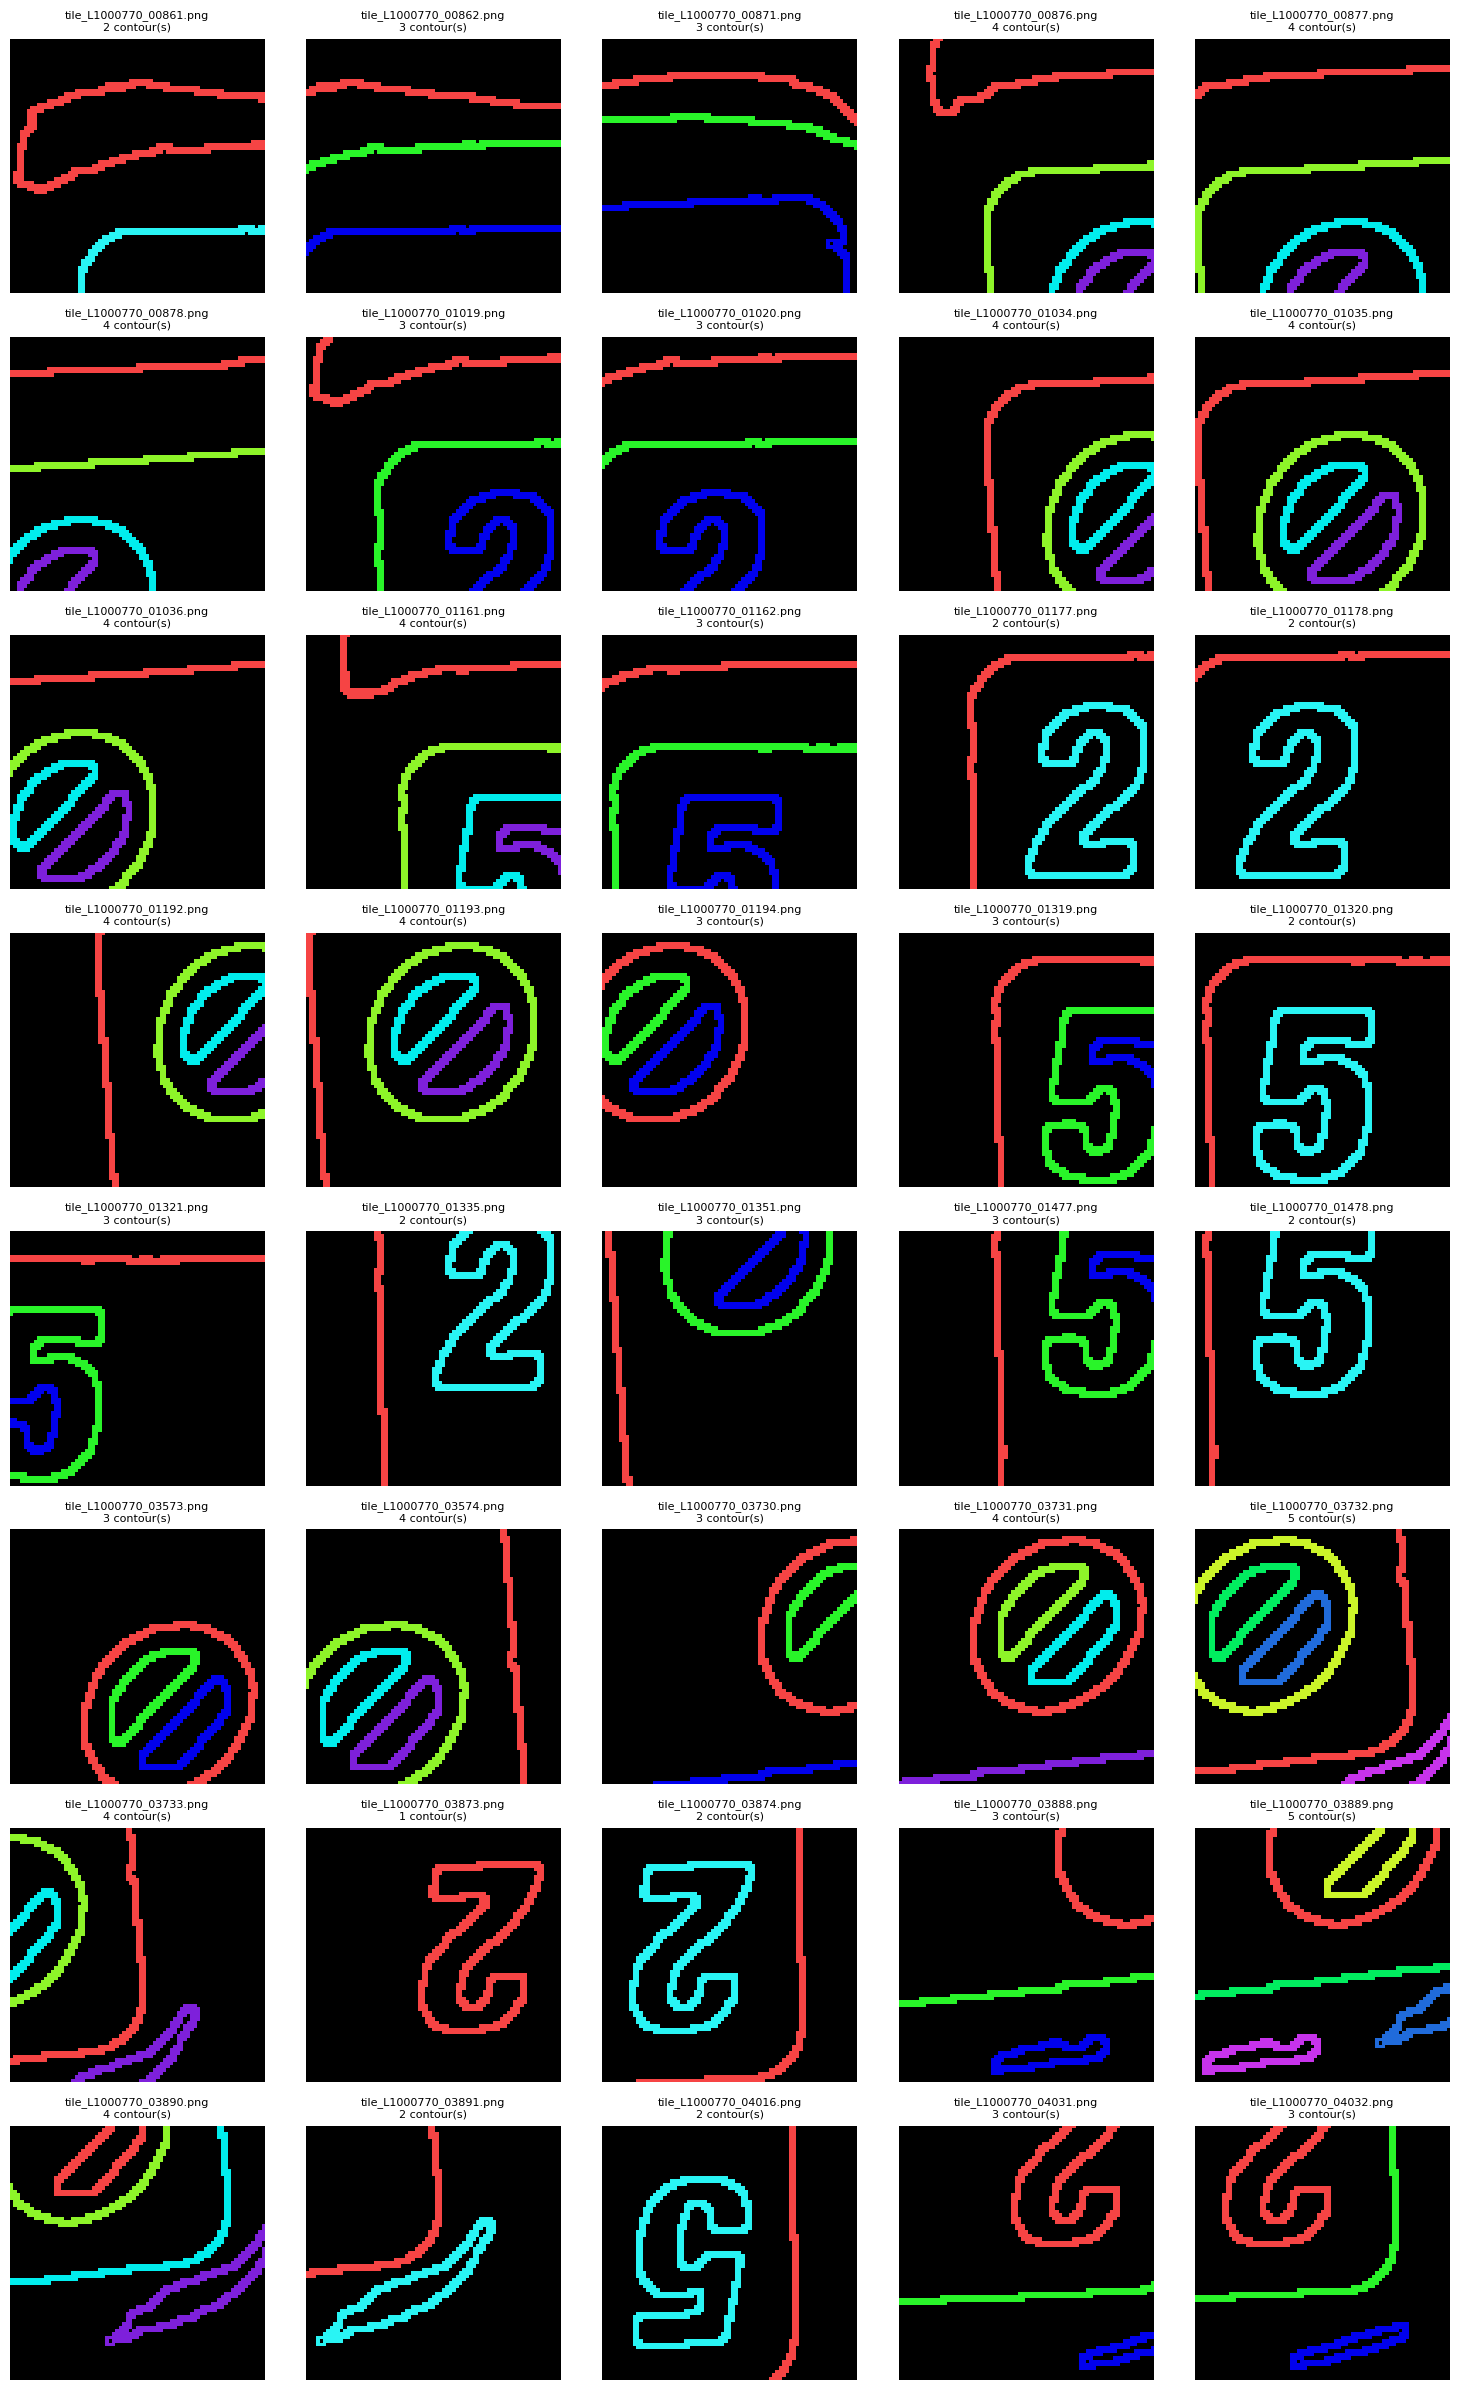

In [11]:
# === Cell 3 — Run on all tiles, filter small contours, display in a grid ===
MIN_PIXELS = 100
results = {}
for name, img in TILES.items():
    labels = label_contours(img > FG_THRESHOLD)            # from-scratch labeling
    labels = remove_small_contours(labels, MIN_PIXELS)     # drop contours < 25 px
    results[name] = (labels, colorize(labels))

ncols = 5
nrows = -(-len(results) // ncols)                          # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.array(axes).reshape(-1)
for ax, (name, (labels, colored)) in zip(axes, results.items()):
    ax.imshow(colored)
    ax.set_title(f"{name}\n{int(labels.max())} contour(s)", fontsize=8)
    ax.axis("off")
for ax in axes[len(results):]:                             # hide unused panels
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# === Cell 4 — Per-tile contour inventory ===
print(f"{'tile':30s} {'#contours':>10s}   pixel count per contour")
print("-" * 72)
for name, (labels, _) in results.items():
    n = int(labels.max())
    sizes = [int((labels == k).sum()) for k in range(1, n + 1)]
    print(f"{name:30s} {n:>10d}   {sorted(sizes, reverse=True)}")


tile                            #contours   pixel count per contour
------------------------------------------------------------------------
tile_L1000770_00861.png                 2   [408, 150]
tile_L1000770_00862.png                 3   [174, 173, 167]
tile_L1000770_00871.png                 3   [223, 183, 169]
tile_L1000770_00876.png                 4   [205, 176, 103, 102]
tile_L1000770_00877.png                 4   [228, 178, 166, 107]
tile_L1000770_00878.png                 4   [160, 158, 148, 107]
tile_L1000770_01019.png                 3   [288, 230, 206]
tile_L1000770_01020.png                 3   [288, 173, 167]
tile_L1000770_01034.png                 4   [230, 191, 172, 107]
tile_L1000770_01035.png                 4   [319, 282, 204, 196]
tile_L1000770_01036.png                 4   [220, 204, 196, 160]
tile_L1000770_01161.png                 4   [195, 188, 155, 101]
tile_L1000770_01162.png                 3   [299, 250, 167]
tile_L1000770_01177.png                 2   [512,